# DK1 Electricity Price Forecasting — Exploratory Data Analysis

This notebook explores the full dataset guided by the literature review. The analysis follows the predictor importance ranking synthesised across 30+ papers:

| Rank | Variable | Key source |
|------|----------|------------|
| 1 | Wind power production | Liu 2023; Jónsson 2013 |
| 2 | Lagged prices (24h, 168h) | Lago 2021; Uniejewski 2018 |
| 3 | Cross-border flows (DK1↔DE) | Li & Becker 2021; Liu 2023 |
| 4 | Load / consumption | Becker & Blatt 2020 |
| 5 | Commodity prices (TTF, EUA) | Tschora 2022; Trebbien 2023 |
| 6 | Calendar effects | Uniejewski 2018 |
| 7 | Climate (wind speed, temperature) | Karabiber 2019 |

## 0 · Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from epf.data import (
    load_prices,
    load_loads,
    load_renewables,
    load_transmission,
    load_commodity,
    load_macro_daily,
    load_climate,
)
from epf.data.loaders import net_dk1_flows
from epf.eda import descriptive, temporal, relationships

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120

DATA = Path("..") / "data"

## 1 · Load all datasets

In [2]:
# ── ENTSO-E ──────────────────────────────────────────────────────────────────
prices_df   = load_prices(DATA)
loads_df    = load_loads(DATA)
wind_on     = load_renewables(DATA, source="onshore")
wind_off    = load_renewables(DATA, source="offshore")
solar_df    = load_renewables(DATA, source="solar")
flows_long  = load_transmission(DATA)
net_flows   = net_dk1_flows(flows_long)

# ── Convenience series ───────────────────────────────────────────────────────
price       = prices_df["price"]
load_actual = loads_df["actual_load"]
load_fc     = loads_df["forecast_load"]
wind_on_act = wind_on["actual"]
wind_off_act= wind_off["actual"]
solar_act   = solar_df["actual"]

# ── Commodities ──────────────────────────────────────────────────────────────
gas  = load_commodity(DATA, "Natural_Gas")
eua  = load_commodity(DATA, "EUA")
coal = load_commodity(DATA, "Coal")
oil  = load_commodity(DATA, "Oil")

# ── Climate ──────────────────────────────────────────────────────────────────
fg = load_climate(DATA, "fg")  # wind speed (0.1 m/s)
tg = load_climate(DATA, "tg")  # temperature (0.1 °C)

print(f"Price series: {price.index.min().date()} → {price.index.max().date()}  "
      f"({len(price):,} obs, {price.isna().mean():.1%} NaN)")
print(f"Net flows partners: {list(net_flows.columns)}")

Price series: 2014-12-31 → 2025-12-19  (96,144 obs, 0.0% NaN)
Net flows partners: ['DE-AT-LU', 'DE-LU', 'DK1A', 'DK2', 'GB', 'NL', 'NO2', 'SE3']


---
## 2 · Price Series Overview

DK1 prices can go deeply negative (excess wind) and spike above 1,000 EUR/MWh during the 2021-22 energy crisis.  
The orange band marks the crisis period referenced throughout the literature.

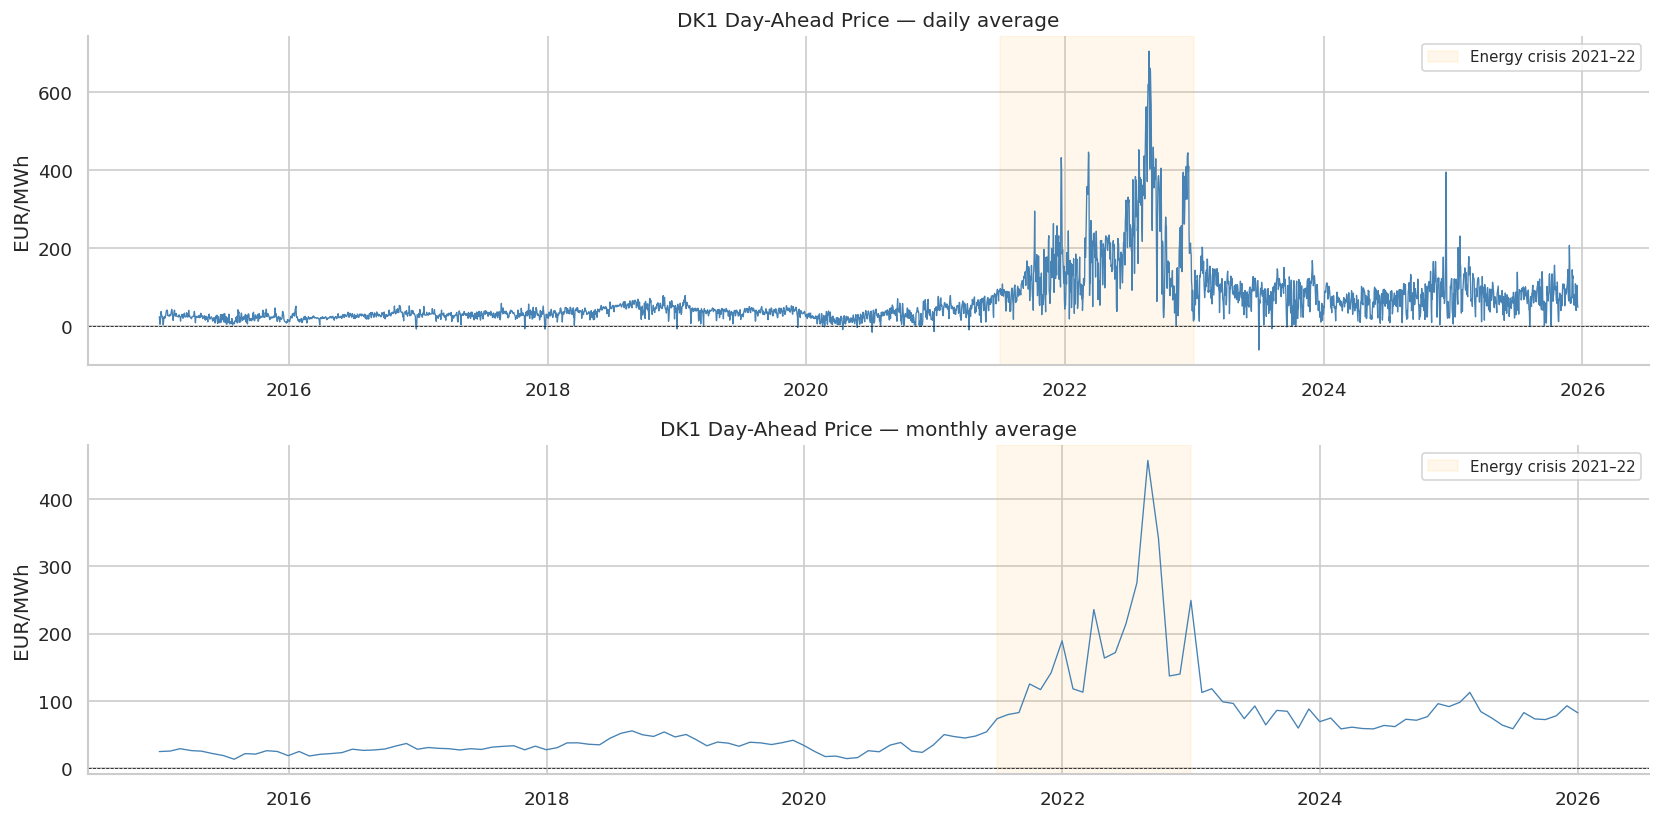

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
descriptive.plot_price_series(price, resample="D", ax=axes[0], crisis_shade=True)
descriptive.plot_price_series(price, resample="ME", ax=axes[1], crisis_shade=True)
axes[0].set_title("DK1 Day-Ahead Price — daily average")
axes[1].set_title("DK1 Day-Ahead Price — monthly average")
fig.tight_layout()

/home/clayt/Electricity-Price-Forecasting/src/epf/eda/descriptive.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: title={'center': 'Annual price distribution (whiskers = 5th–95th pct)'}, ylabel='EUR/MWh'>

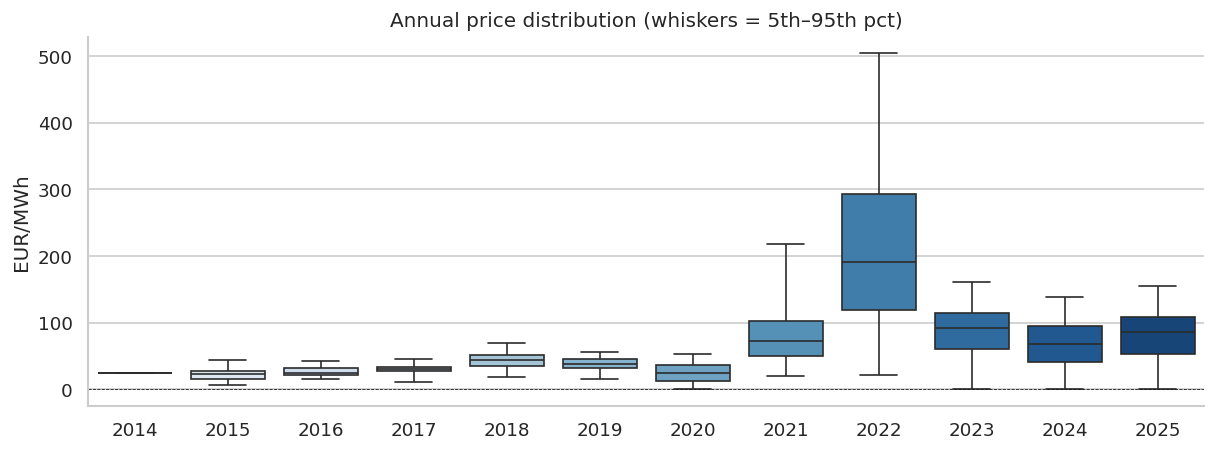

In [7]:
descriptive.plot_annual_boxplots(price)

### 2.1 Summary statistics

In [8]:
stats = descriptive.summary_stats(price)
stats.style.format("{:.2f}", subset=stats.columns[:-1]).set_caption("DK1 hourly price statistics")

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,All
N (obs),1.00,8760.00,8784.00,8760.00,8760.00,8760.00,8784.00,8760.00,8760.00,8760.00,8784.00,8471.00,96144.000000
Mean,25.02,22.89,26.67,30.08,44.05,38.49,24.99,88.14,219.03,86.83,70.64,81.06,66.560000
Median,25.02,23.68,24.78,30.12,44.18,38.75,23.86,73.26,190.62,92.04,67.90,85.66,41.080000
Std,nan,11.12,9.76,10.68,15.06,13.16,17.44,64.78,145.45,48.82,50.16,51.24,77.570000
Min,25.02,-31.41,-53.62,-50.04,-15.00,-48.29,-58.80,-43.91,-19.04,-440.10,-60.05,-38.14,-440.100000
Max,25.02,99.77,104.96,120.01,144.33,109.45,200.04,620.00,871.00,524.27,936.28,583.40,936.280000
% negative,0.00,0.70,0.70,1.00,0.60,1.50,2.20,1.00,0.40,3.20,4.30,5.20,1.900000
% > 200 EUR/MWh,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.40,46.10,1.20,1.20,1.70,5.100000
Skewness,nan,0.65,0.49,0.01,-0.04,-0.70,0.79,2.32,1.01,-0.19,3.14,0.86,3.440000
Kurtosis,nan,1.84,6.66,7.44,1.78,3.76,3.60,8.30,1.02,4.43,32.78,4.67,16.650000


### 2.2 Price distribution

Heavy right tail (energy crisis spikes) and a left mass of negative prices driven by excess wind generation.  
Karabiber & Xydis (2019) note that temperature **exclusion** improved DK1 forecasts — a sign that the distribution
already captures most of temperature's influence through wind and load.

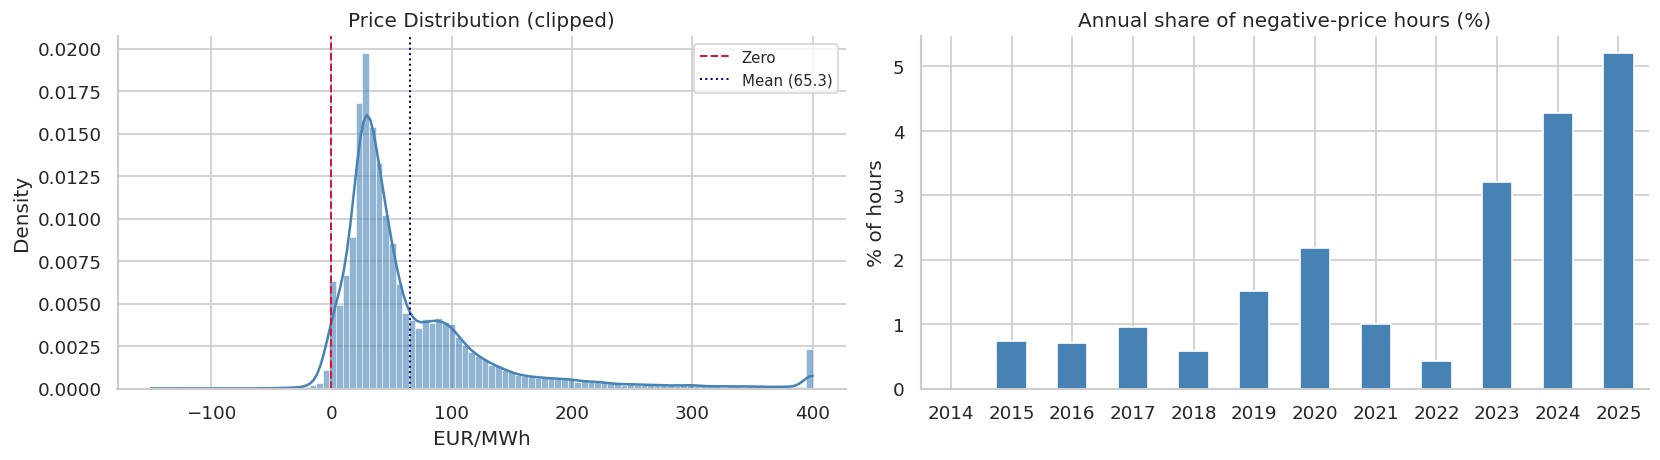

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
descriptive.plot_price_distribution(price, ax=axes[0], clip=(-150, 400))
descriptive.plot_negative_prices(price, ax=axes[1])
fig.tight_layout()

---
## 3 · Calendar Seasonality

Calendar effects are consistently selected by LASSO across all EPF studies (Uniejewski et al. 2018; Lago et al. 2021).  
The dual-peak intra-day profile (morning + evening ramp) and the winter premium are characteristic of DK1.

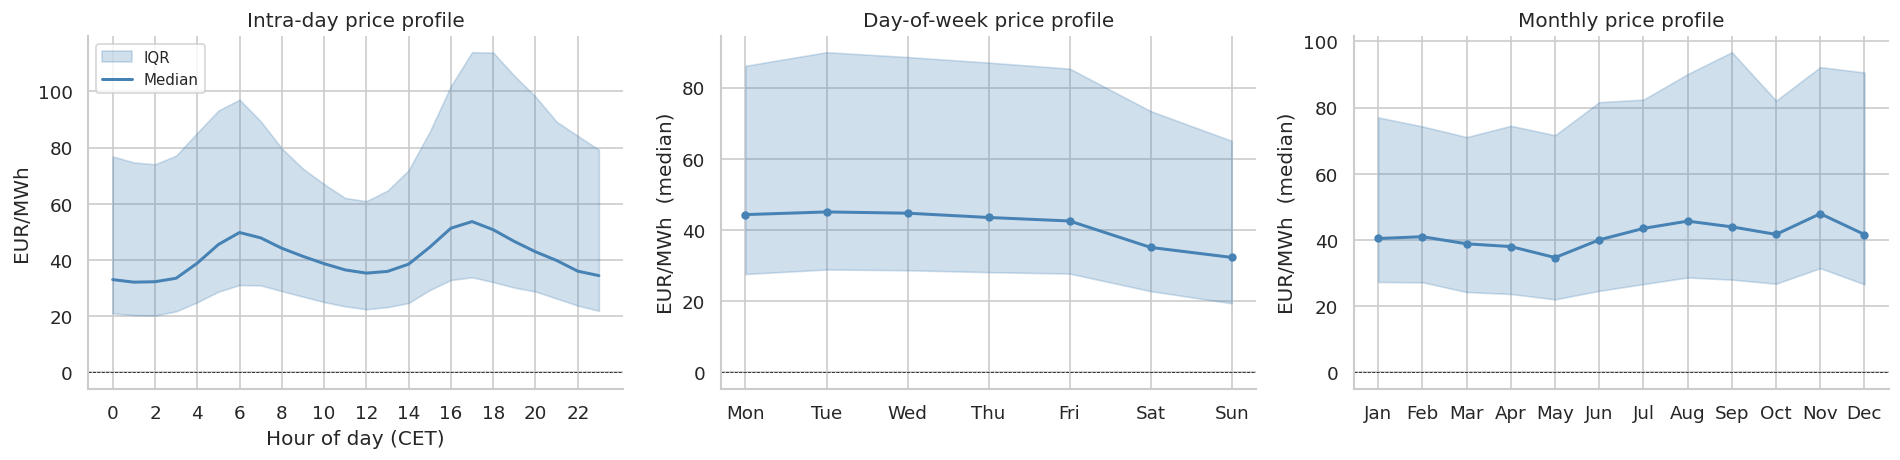

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
temporal.plot_hourly_profile(price, ax=axes[0])
temporal.plot_dow_profile(price, ax=axes[1])
temporal.plot_monthly_profile(price, ax=axes[2])
fig.tight_layout()

<Axes: title={'center': 'Median price by hour × month (EUR/MWh)'}, ylabel='Hour of day'>

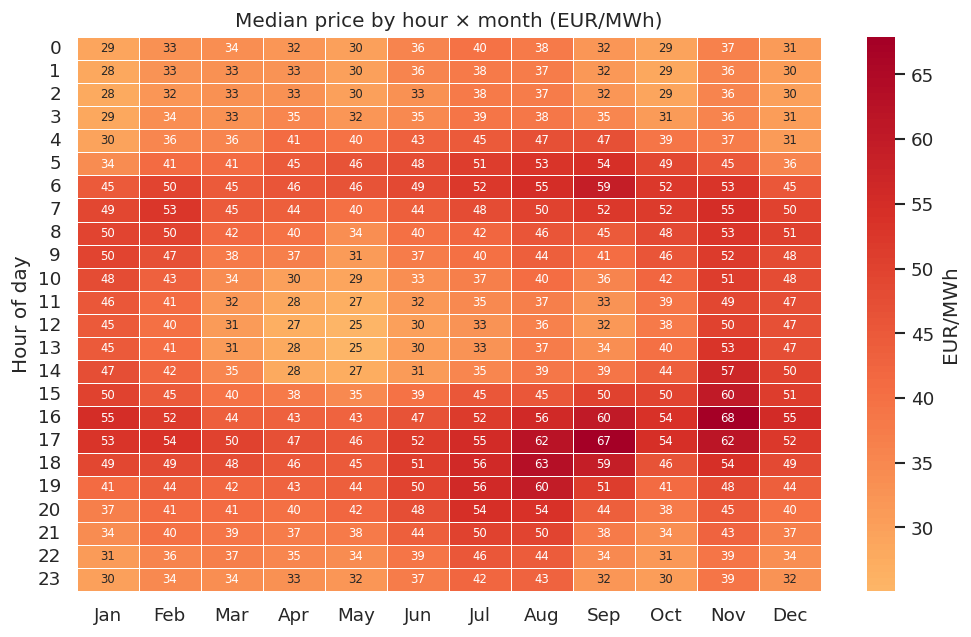

In [11]:
temporal.plot_heatmap_hour_month(price)

---
## 4 · Autocorrelation Structure

The LEAR benchmark (Lago et al. 2021) uses lags **d−1, d−2, d−3, d−7** (i.e. 24h, 48h, 72h, 168h).  
Liu et al. (2023) SHAP analysis ranks the **7-day lag** as the single most predictive feature for DK1,
driven by the weekly dispatch cycle and cross-Great-Belt synchronisation with DK2.

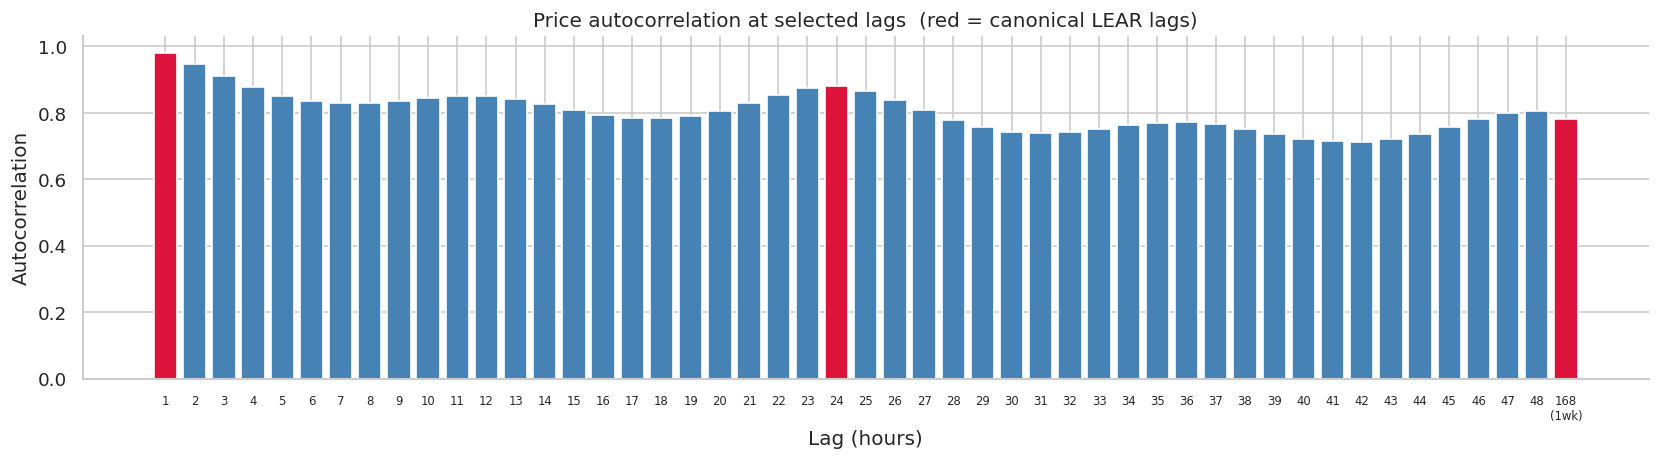

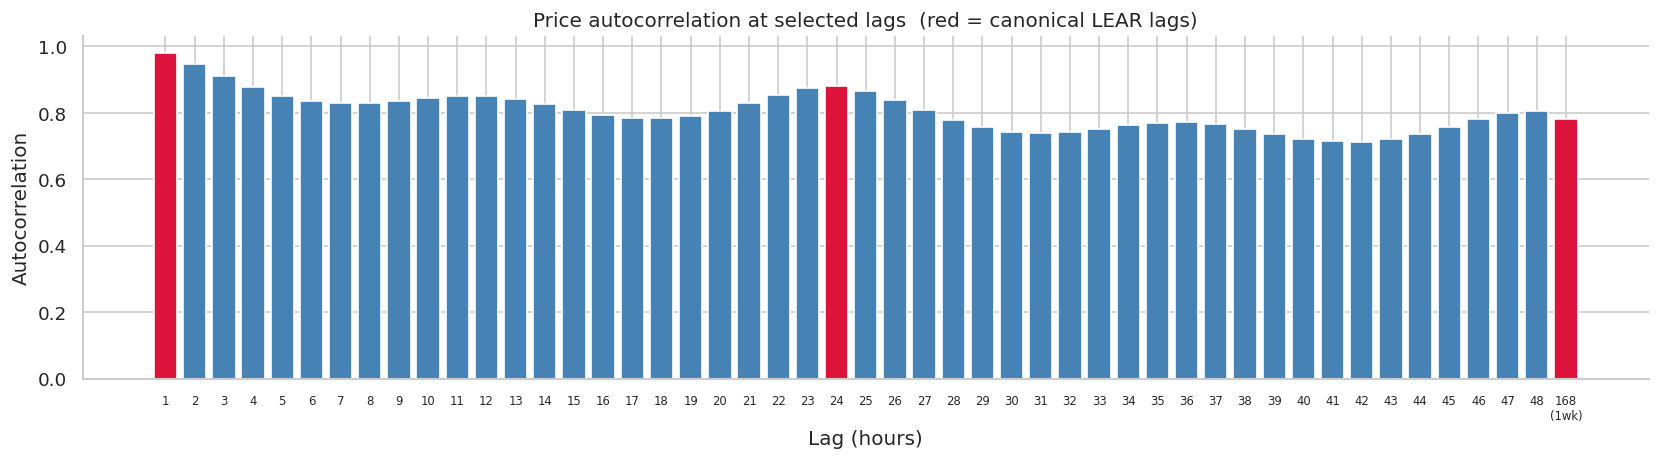

In [12]:
# Fast manual bar chart — avoids expensive statsmodels ACF for full series
temporal.plot_acf_manual(price)

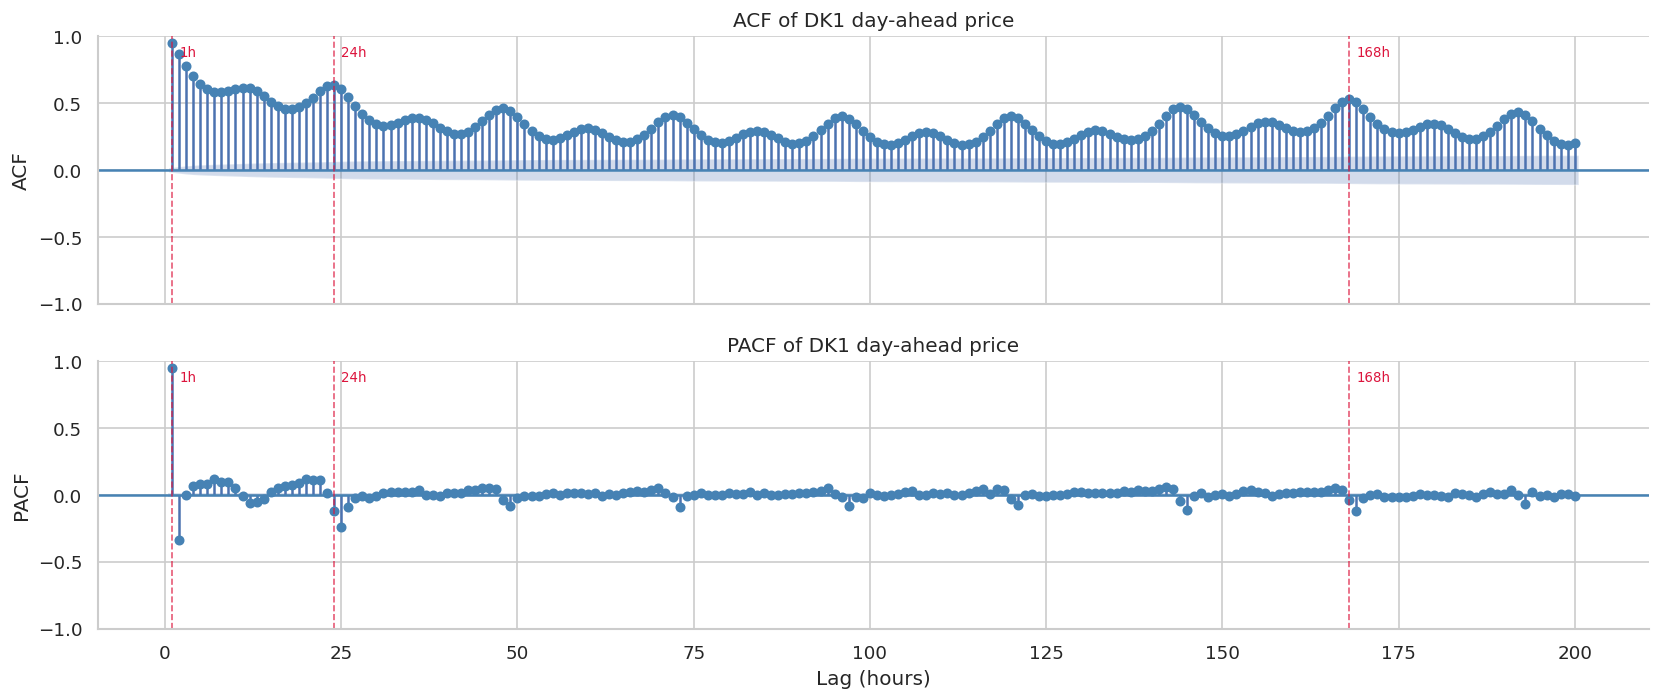

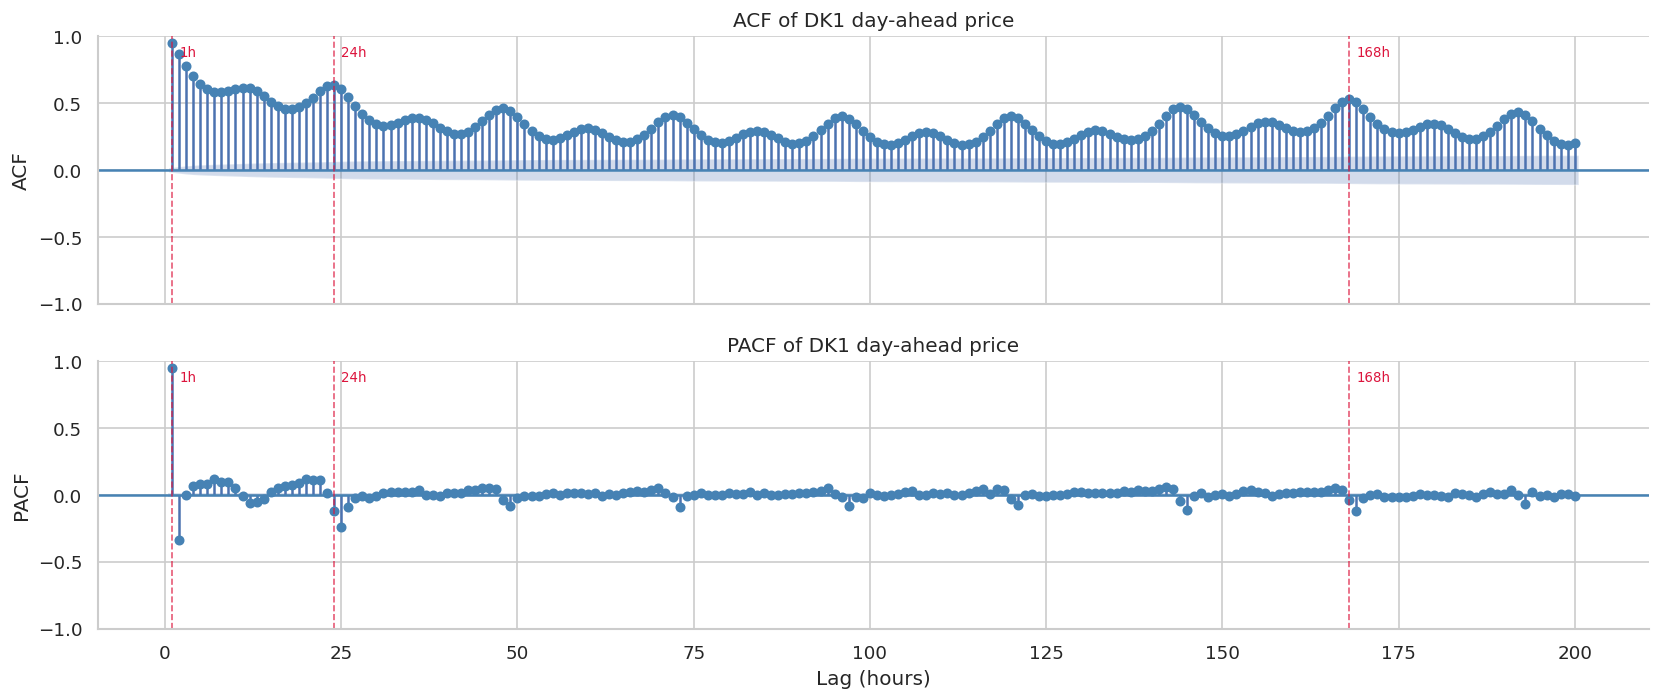

In [13]:
# Formal ACF / PACF (computed on a 2-year window for speed)
price_window = price.loc["2019":"2020"].dropna()
temporal.plot_acf_key_lags(price_window, max_lag=200)

---
## 5 · Wind Power — Rank 1 Predictor

DK1 has ~49% wind penetration (Becker & Blatt 2020).  
The wind-price relationship is **nonlinear**: prices plateau at high wind because surplus is exported
or absorbed by storage, but sufficiently high wind triggers negative prices (merit-order inversion).  
Jónsson et al. (2013) show that explicitly modelling this nonlinearity significantly improves forecasts.

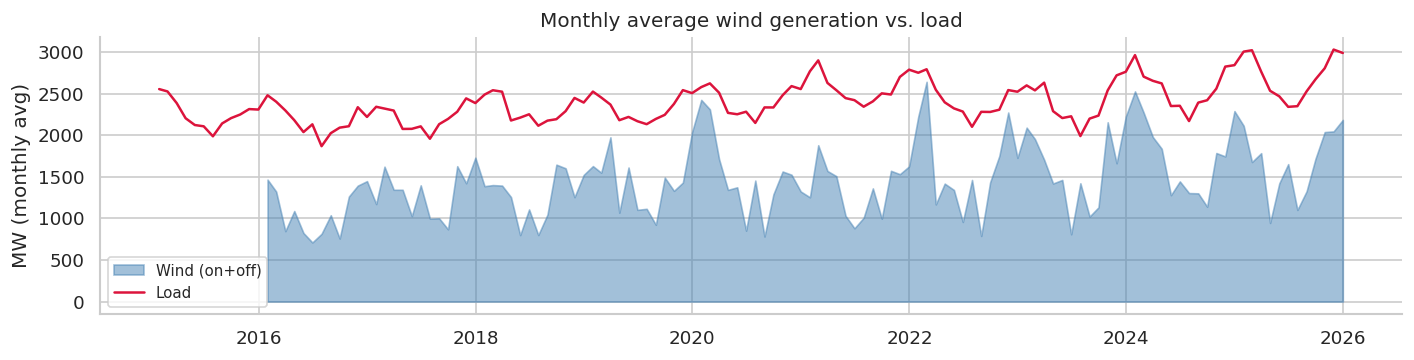

In [14]:
# Wind generation time series
fig, ax = plt.subplots(figsize=(14, 3))
wind_total_monthly = (wind_on_act + wind_off_act).resample("ME").mean()
load_monthly = load_actual.resample("ME").mean()
ax.fill_between(wind_total_monthly.index, wind_total_monthly.values, alpha=0.5,
                color="steelblue", label="Wind (on+off)")
ax.plot(load_monthly.index, load_monthly.values, color="crimson", lw=1.5, label="Load")
ax.set_ylabel("MW (monthly avg)")
ax.set_title("Monthly average wind generation vs. load")
ax.legend(fontsize=9)
sns.despine(ax=ax)

<Axes: title={'center': 'Monthly average wind penetration in DK1'}, ylabel='Wind / Load  (%)'>

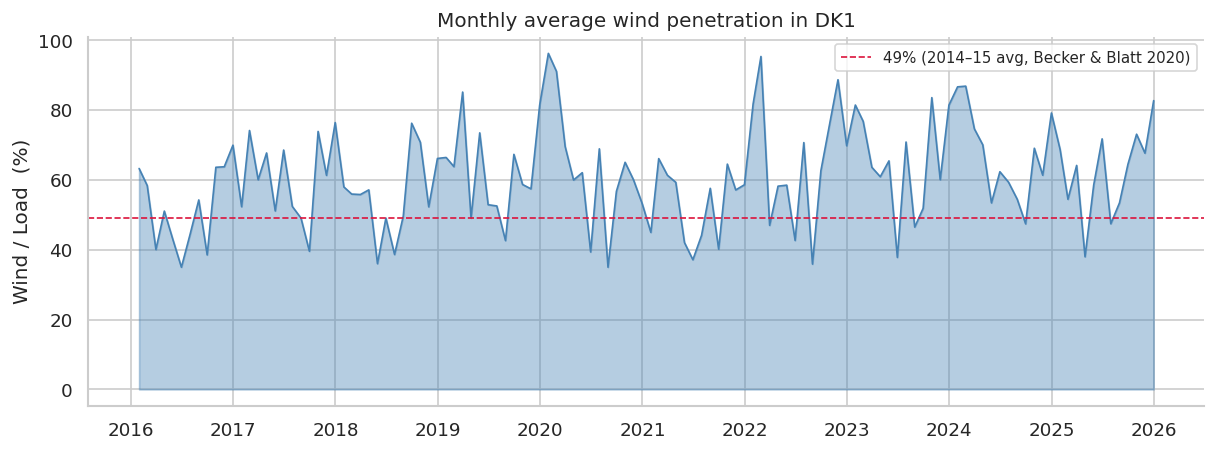

In [15]:
relationships.plot_wind_share_series(wind_on_act, wind_off_act, load_actual)

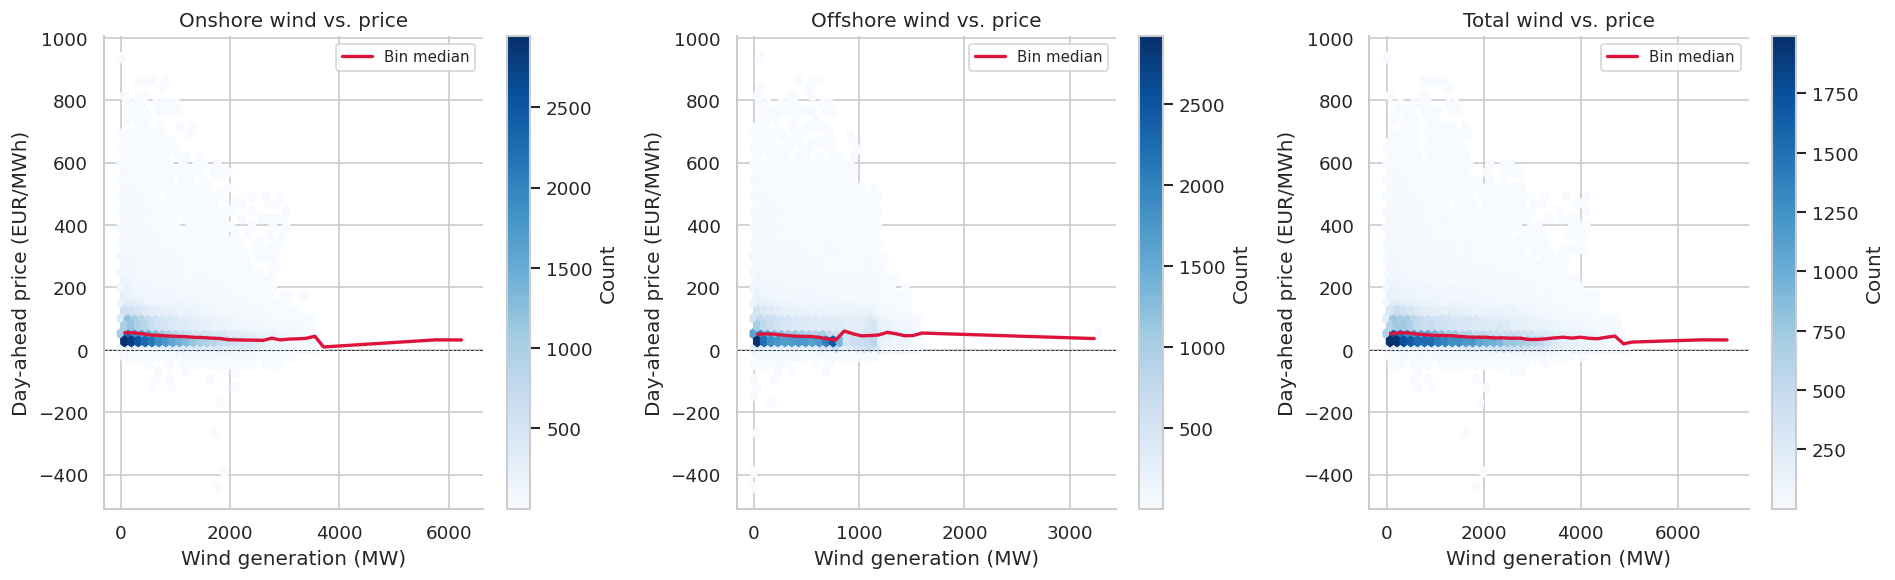

In [16]:
# Wind vs price scatter (hexbin density)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
relationships.plot_wind_price_scatter(price, wind_on_act, ax=axes[0])
axes[0].set_title("Onshore wind vs. price")
relationships.plot_wind_price_scatter(price, wind_off_act, ax=axes[1])
axes[1].set_title("Offshore wind vs. price")
relationships.plot_wind_price_scatter(price, wind_on_act + wind_off_act, ax=axes[2])
axes[2].set_title("Total wind vs. price")
fig.tight_layout()

---
## 6 · Cross-Border Flows — Rank 3 Predictor

Li & Becker (2021) find the DK1↔Germany flow is among the most predictive features in Nordic EPF.
Liu et al. (2023) document a **~800 MW threshold** on the DK1–Germany interconnector:
below it, higher export raises DK1 prices; above it, the relationship reverses.

In [17]:
print("Available partner zones:", list(net_flows.columns))
net_flows.describe().round(1)

Available partner zones: ['DE-AT-LU', 'DE-LU', 'DK1A', 'DK2', 'GB', 'NL', 'NO2', 'SE3']


partner,DE-AT-LU,DE-LU,DK1A,DK2,GB,NL,NO2,SE3
count,96388.0,96388.0,96388.0,96388.0,96388.0,96388.0,96388.0,96388.0
mean,-39.5,203.7,0.0,219.1,65.5,63.6,-476.3,-84.5
std,438.9,923.2,0.0,341.4,377.5,388.2,958.2,476.1
min,-1768.8,-2752.9,0.0,-602.5,-1456.0,-708.7,-1703.1,-1022.0
25%,0.0,-6.8,0.0,0.0,0.0,0.0,-1295.7,-525.9
50%,0.0,0.0,0.0,282.5,0.0,0.0,-707.1,-104.7
75%,0.0,665.9,0.0,552.1,0.0,271.6,188.2,325.6
max,1667.2,2827.3,0.0,700.1,1456.0,835.4,2833.4,750.7


<Axes: title={'center': 'DK1 net cross-border flows by partner  (+ = DK1 exports)'}, xlabel='datetime', ylabel='Net export (MW, monthly avg)'>

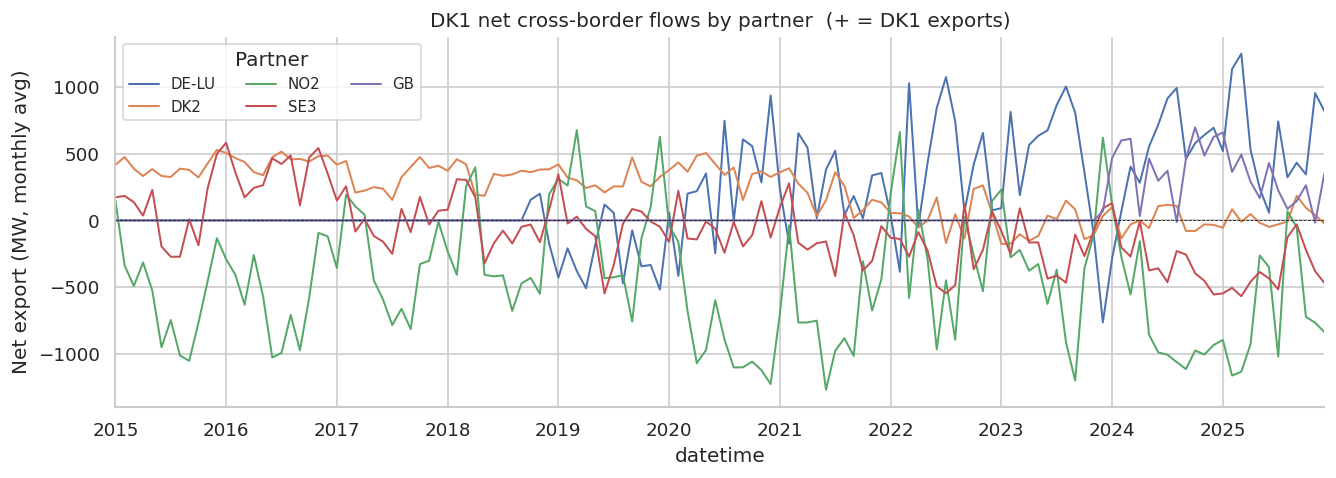

In [18]:
relationships.plot_net_flows(net_flows, resample="ME")

<Axes: title={'center': 'DK1↔Germany flow vs. price'}, xlabel='Net DK1→Germany flow (MW)', ylabel='Day-ahead price (EUR/MWh)'>

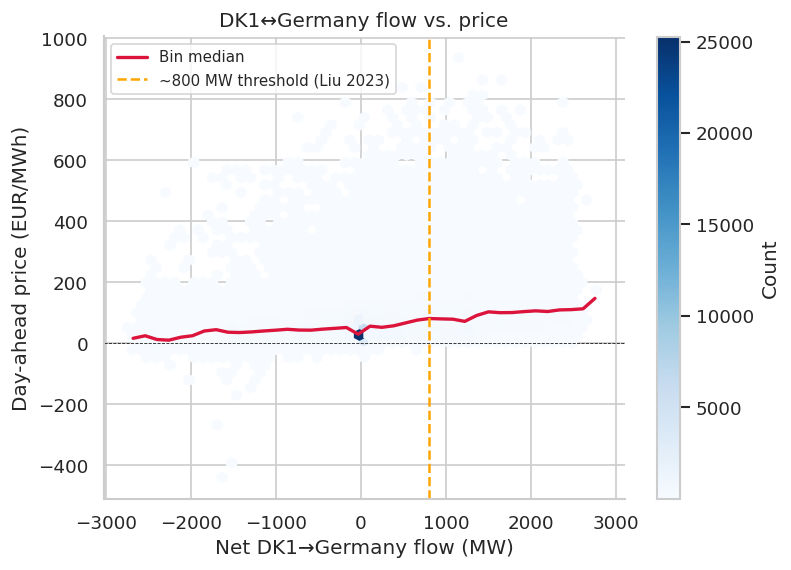

In [19]:
# DK1↔Germany: the dominant coupling partner
de_col = "DE-LU" if "DE-LU" in net_flows.columns else net_flows.columns[0]
relationships.plot_de_flow_price_scatter(price, net_flows, partner_col=de_col)

---
## 7 · Load Analysis — Rank 4 Predictor

Load is less dominant in DK1 than in thermal-dominated systems because renewable dispatch
shapes prices more than demand cycles. Nevertheless it is consistently retained by LASSO.

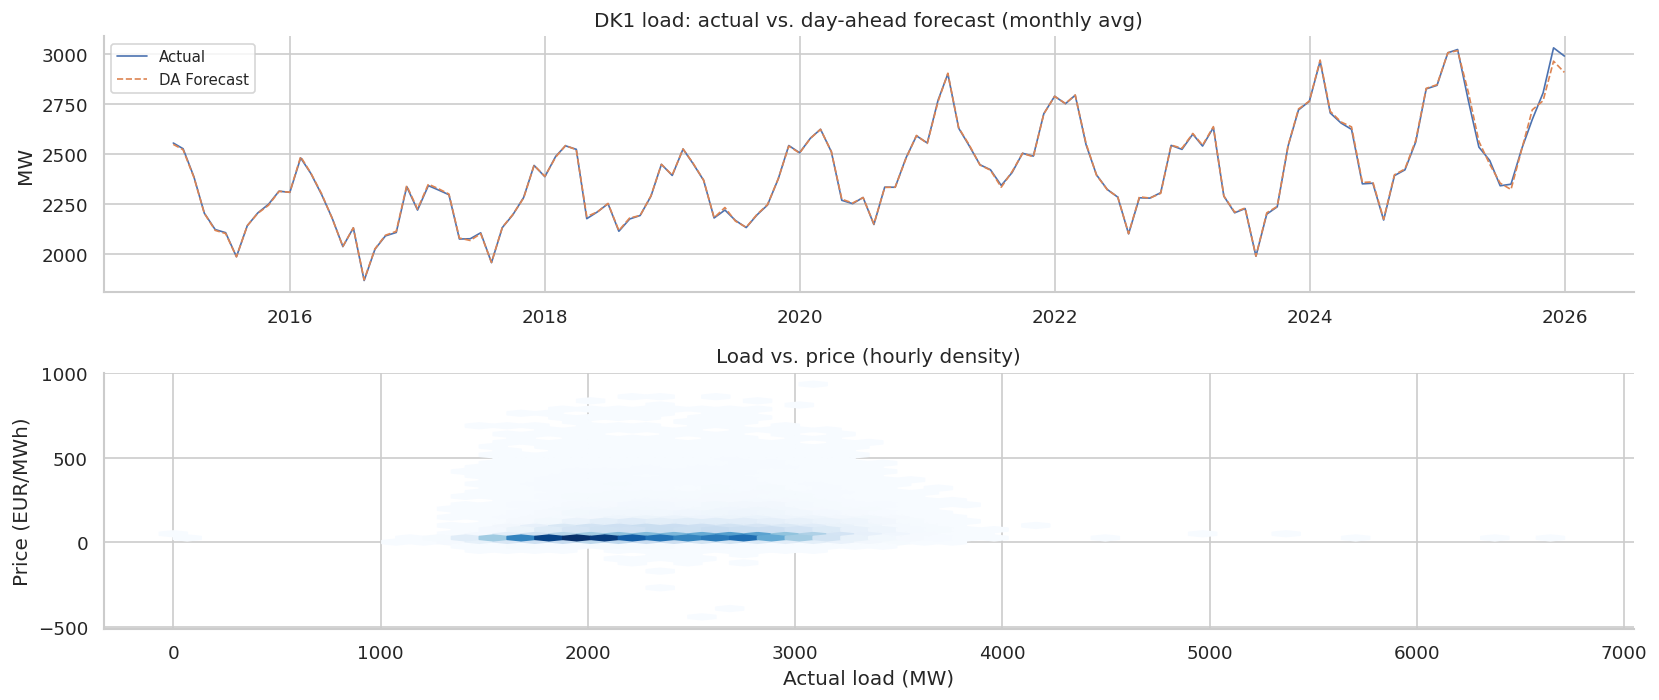

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Actual vs forecast
load_daily = loads_df.resample("ME").mean()
axes[0].plot(load_daily.index, load_daily["actual_load"], lw=1.0, label="Actual")
axes[0].plot(load_daily.index, load_daily["forecast_load"], lw=1.0, ls="--", label="DA Forecast")
axes[0].set_ylabel("MW")
axes[0].set_title("DK1 load: actual vs. day-ahead forecast (monthly avg)")
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# Load vs price scatter
df_lp = pd.concat([price.rename("price"), load_actual.rename("load")], axis=1).dropna()
axes[1].hexbin(df_lp["load"], df_lp["price"], gridsize=50, cmap="Blues", mincnt=1)
axes[1].set_xlabel("Actual load (MW)")
axes[1].set_ylabel("Price (EUR/MWh)")
axes[1].set_title("Load vs. price (hourly density)")
sns.despine(ax=axes[1])

fig.tight_layout()

---
## 8 · Commodity Prices — Rank 5–6 Predictors

Gas prices (TTF) surged from a moderate predictor to the dominant one during the 2021–22 energy crisis
(Tschora et al. 2022). CO2/EUA prices are positively linked with Nordic market risk (2024 Energy Economics).
Trebbien et al. (2023) caution against including EUA in ML models due to its near-monotonic trend pre-2021.

<Axes: title={'center': 'Commodity prices (z-score normalised)'}, ylabel='Z-score'>

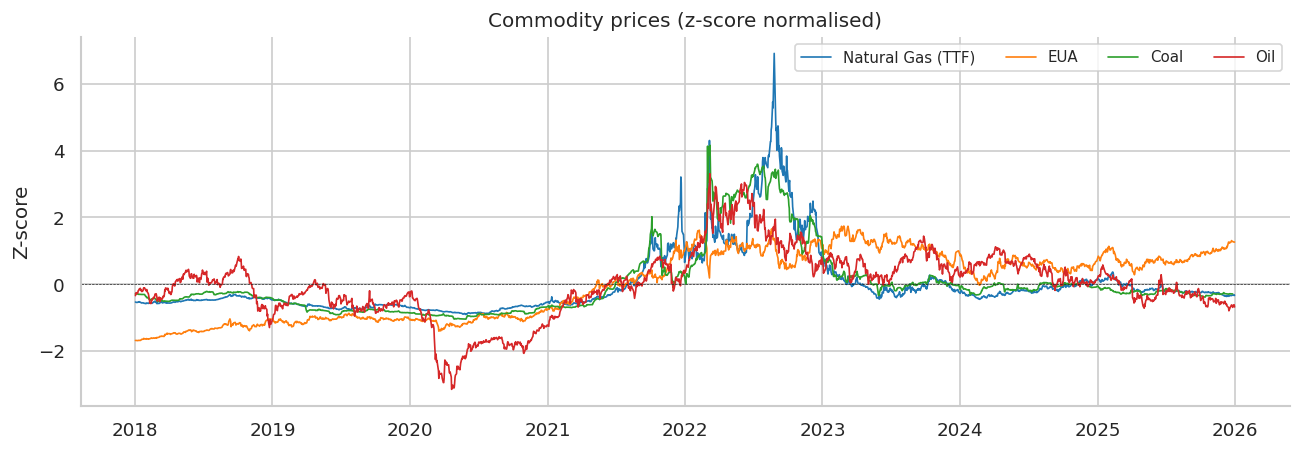

In [21]:
relationships.plot_commodities({"Natural Gas (TTF)": gas, "EUA": eua, "Coal": coal, "Oil": oil})

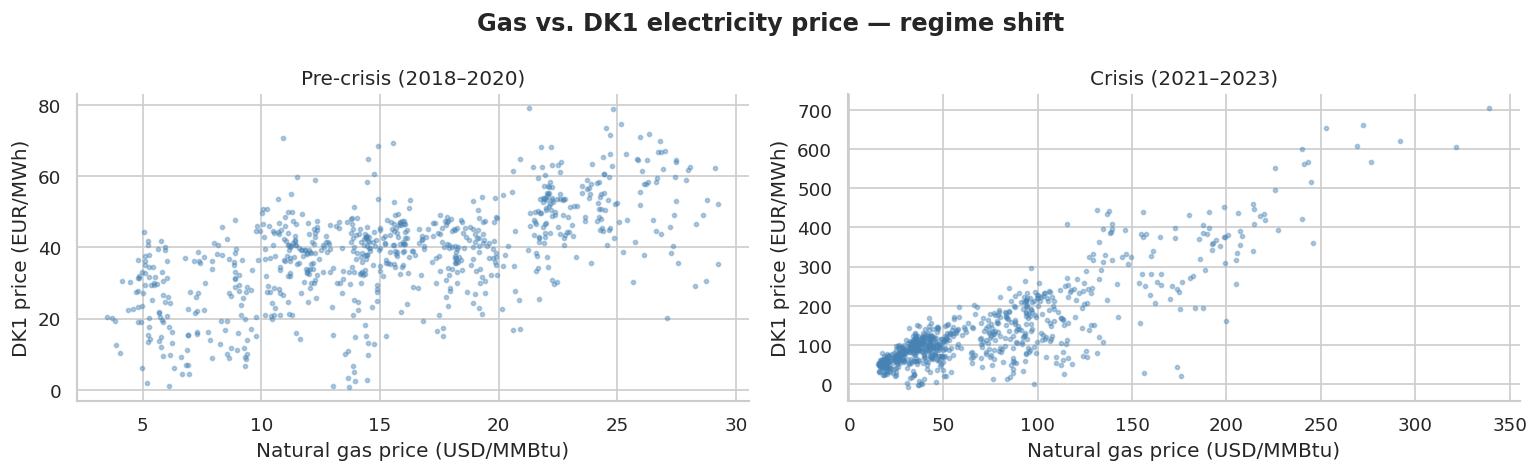

In [22]:
# Price vs gas scatter (daily averages)
price_daily = price.resample("D").mean()
df_pg = pd.concat([price_daily.rename("price"), gas.rename("gas")], axis=1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, era, label in zip(
    axes,
    [slice("2018", "2020"), slice("2021", "2023")],
    ["Pre-crisis (2018–2020)", "Crisis (2021–2023)"],
):
    sub = df_pg.loc[era]
    ax.scatter(sub["gas"], sub["price"], alpha=0.4, s=6, color="steelblue")
    ax.set_xlabel("Natural gas price (USD/MMBtu)")
    ax.set_ylabel("DK1 price (EUR/MWh)")
    ax.set_title(label)
    sns.despine(ax=ax)
fig.suptitle("Gas vs. DK1 electricity price — regime shift", fontweight="bold")
fig.tight_layout()

---
## 9 · Solar Generation

Solar ranks 11th in the literature — still a small share of DK1 generation but growing.  
Its effect is already captured implicitly through hourly load profiles.

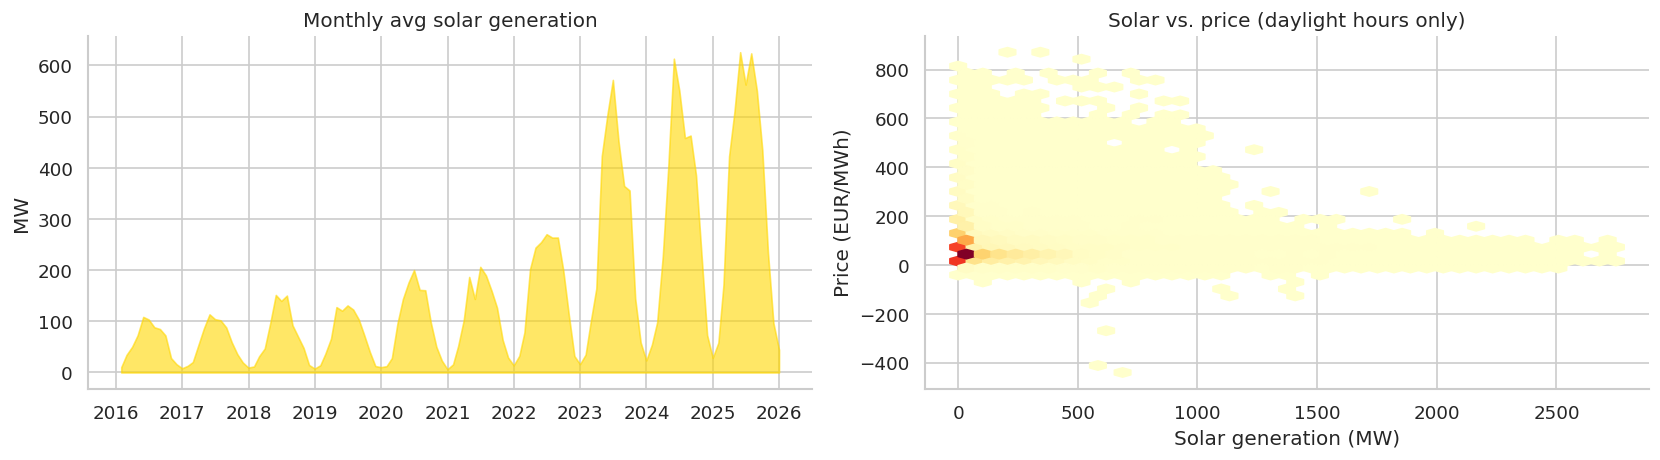

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

solar_monthly = solar_act.resample("ME").mean()
axes[0].fill_between(solar_monthly.index, solar_monthly.values, alpha=0.6, color="gold")
axes[0].set_ylabel("MW")
axes[0].set_title("Monthly avg solar generation")
sns.despine(ax=axes[0])

# Solar vs price — check for merit-order displacement at midday
df_sp = pd.concat([price.rename("price"), solar_act.rename("solar")], axis=1).dropna()
df_sp = df_sp[df_sp["solar"] > 0]  # only daylight hours
axes[1].hexbin(df_sp["solar"], df_sp["price"], gridsize=40, cmap="YlOrRd", mincnt=1)
axes[1].set_xlabel("Solar generation (MW)")
axes[1].set_ylabel("Price (EUR/MWh)")
axes[1].set_title("Solar vs. price (daylight hours only)")
sns.despine(ax=axes[1])
fig.tight_layout()

---
## 10 · Climate Variables

Karabiber & Xydis (2019) found that **excluding temperature improved DK1 forecasts** — its effect is
already captured through wind and load.  
We include wind speed (Esbjerg Airport) as a proxy for the wind-generation signal.

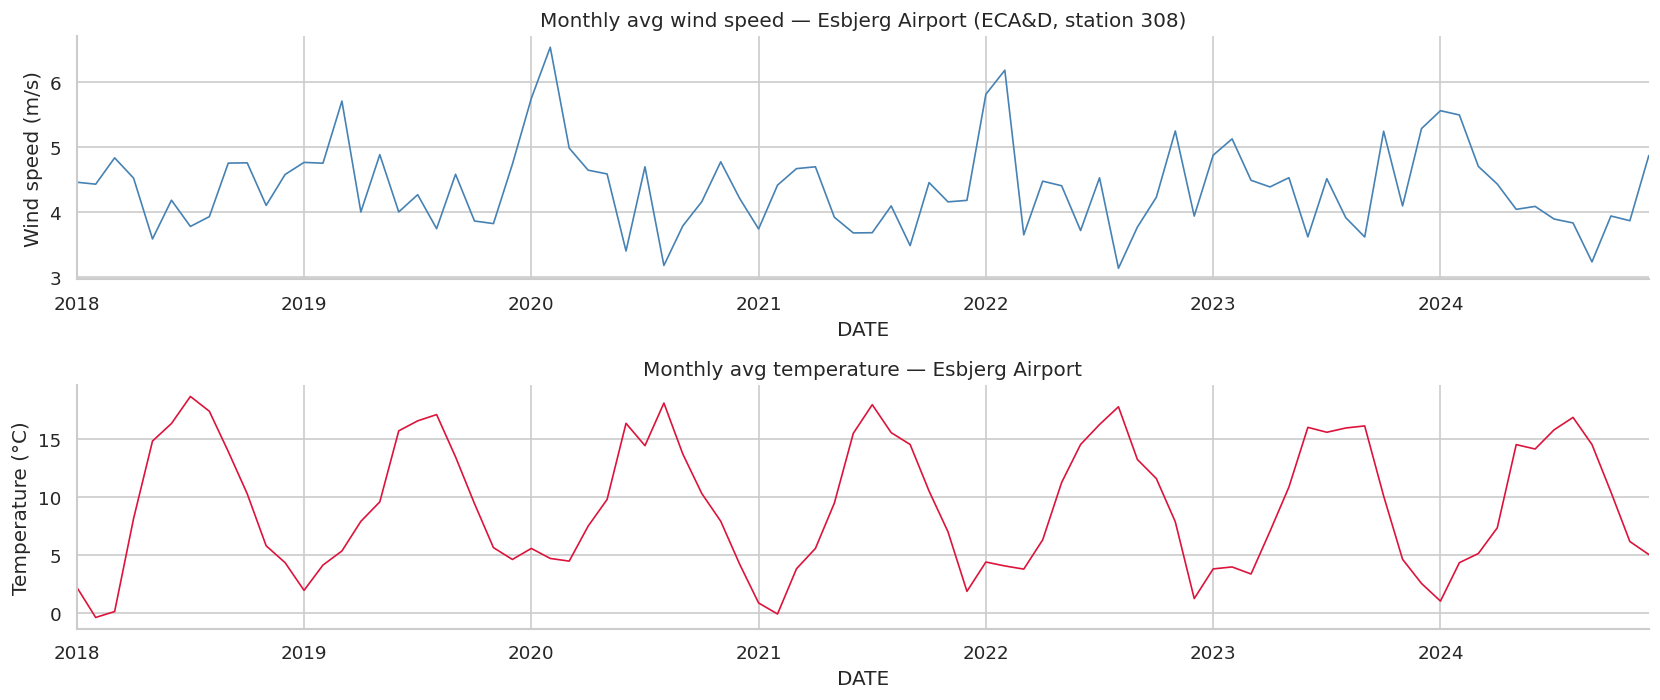

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Wind speed (convert from 0.1 m/s to m/s)
fg_ms = fg / 10
fg_ms.resample("ME").mean().plot(ax=axes[0], color="steelblue", lw=1.0)
axes[0].set_ylabel("Wind speed (m/s)")
axes[0].set_title("Monthly avg wind speed — Esbjerg Airport (ECA&D, station 308)")
sns.despine(ax=axes[0])

# Temperature (convert from 0.1 °C to °C)
tg_c = tg / 10
tg_c.resample("ME").mean().plot(ax=axes[1], color="crimson", lw=1.0)
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Monthly avg temperature — Esbjerg Airport")
sns.despine(ax=axes[1])

fig.tight_layout()

---
## 11 · Correlation Matrix

Spearman correlations on daily-averaged variables confirm the literature ranking:
wind is the strongest driver of price suppression; gas/EUA co-move with prices post-2021.

In [25]:
feat_df = relationships.build_daily_feature_matrix(
    prices=price,
    wind_onshore=wind_on_act,
    wind_offshore=wind_off_act,
    solar=solar_act,
    load=load_actual,
    net_flows=net_flows,
    gas=gas,
    eua=eua,
    wind_speed=fg / 10,
)
print(f"Feature matrix: {feat_df.shape[0]} days × {feat_df.shape[1]} features")
feat_df.describe().round(1)

Feature matrix: 4019 days × 13 features


,price,wind_onshore,wind_offshore,solar,load,flow_DE-LU,flow_DK2,flow_NO2,flow_SE3,gas_price,eua_price,wind_speed_obs,wind_total
count,4007.0,3652.0,3652.0,3652.0,4007.0,4018.0,4018.0,4018.0,4018.0,2055.0,2058.0,2557.0,3652.0
mean,66.6,928.5,522.7,155.6,2398.4,203.5,219.0,-475.9,-84.5,42.5,53.4,4.4,1451.2
std,72.4,669.2,330.3,179.9,322.9,736.4,264.6,802.8,390.0,42.9,27.0,1.6,963.3
min,-60.5,29.2,4.2,0.0,1565.2,-2386.4,-600.0,-1658.4,-776.8,3.5,7.7,1.2,33.7
25%,27.7,369.2,242.9,31.2,2185.5,0.0,36.1,-1121.6,-401.1,17.9,25.1,3.2,628.3
50%,41.8,776.2,486.2,89.6,2386.8,0.0,263.4,-650.4,-96.0,30.5,62.0,4.1,1286.5
75%,80.4,1357.4,745.6,196.9,2614.9,578.2,433.2,67.3,213.7,44.1,77.5,5.3,2127.6
max,705.4,3374.0,1507.4,1103.7,3472.0,2365.6,590.7,1640.0,714.4,339.2,100.3,11.5,4578.7


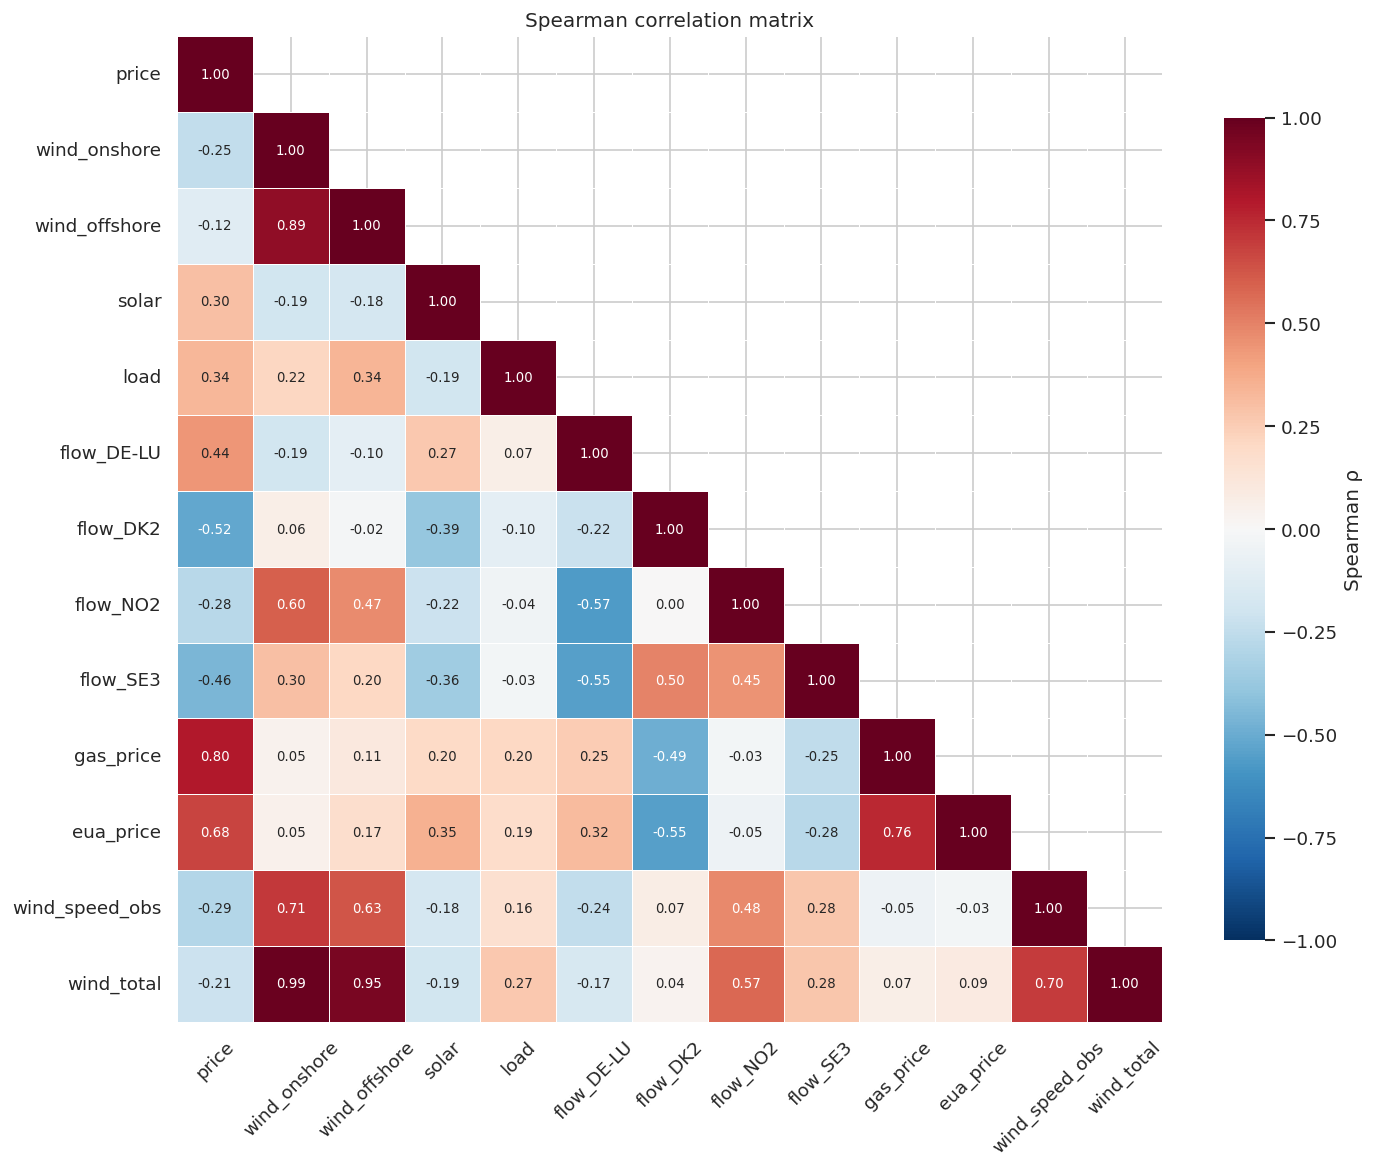

In [26]:
fig, ax = plt.subplots(figsize=(12, 10))
relationships.plot_correlation_matrix(feat_df, method="spearman", ax=ax)
fig.tight_layout()

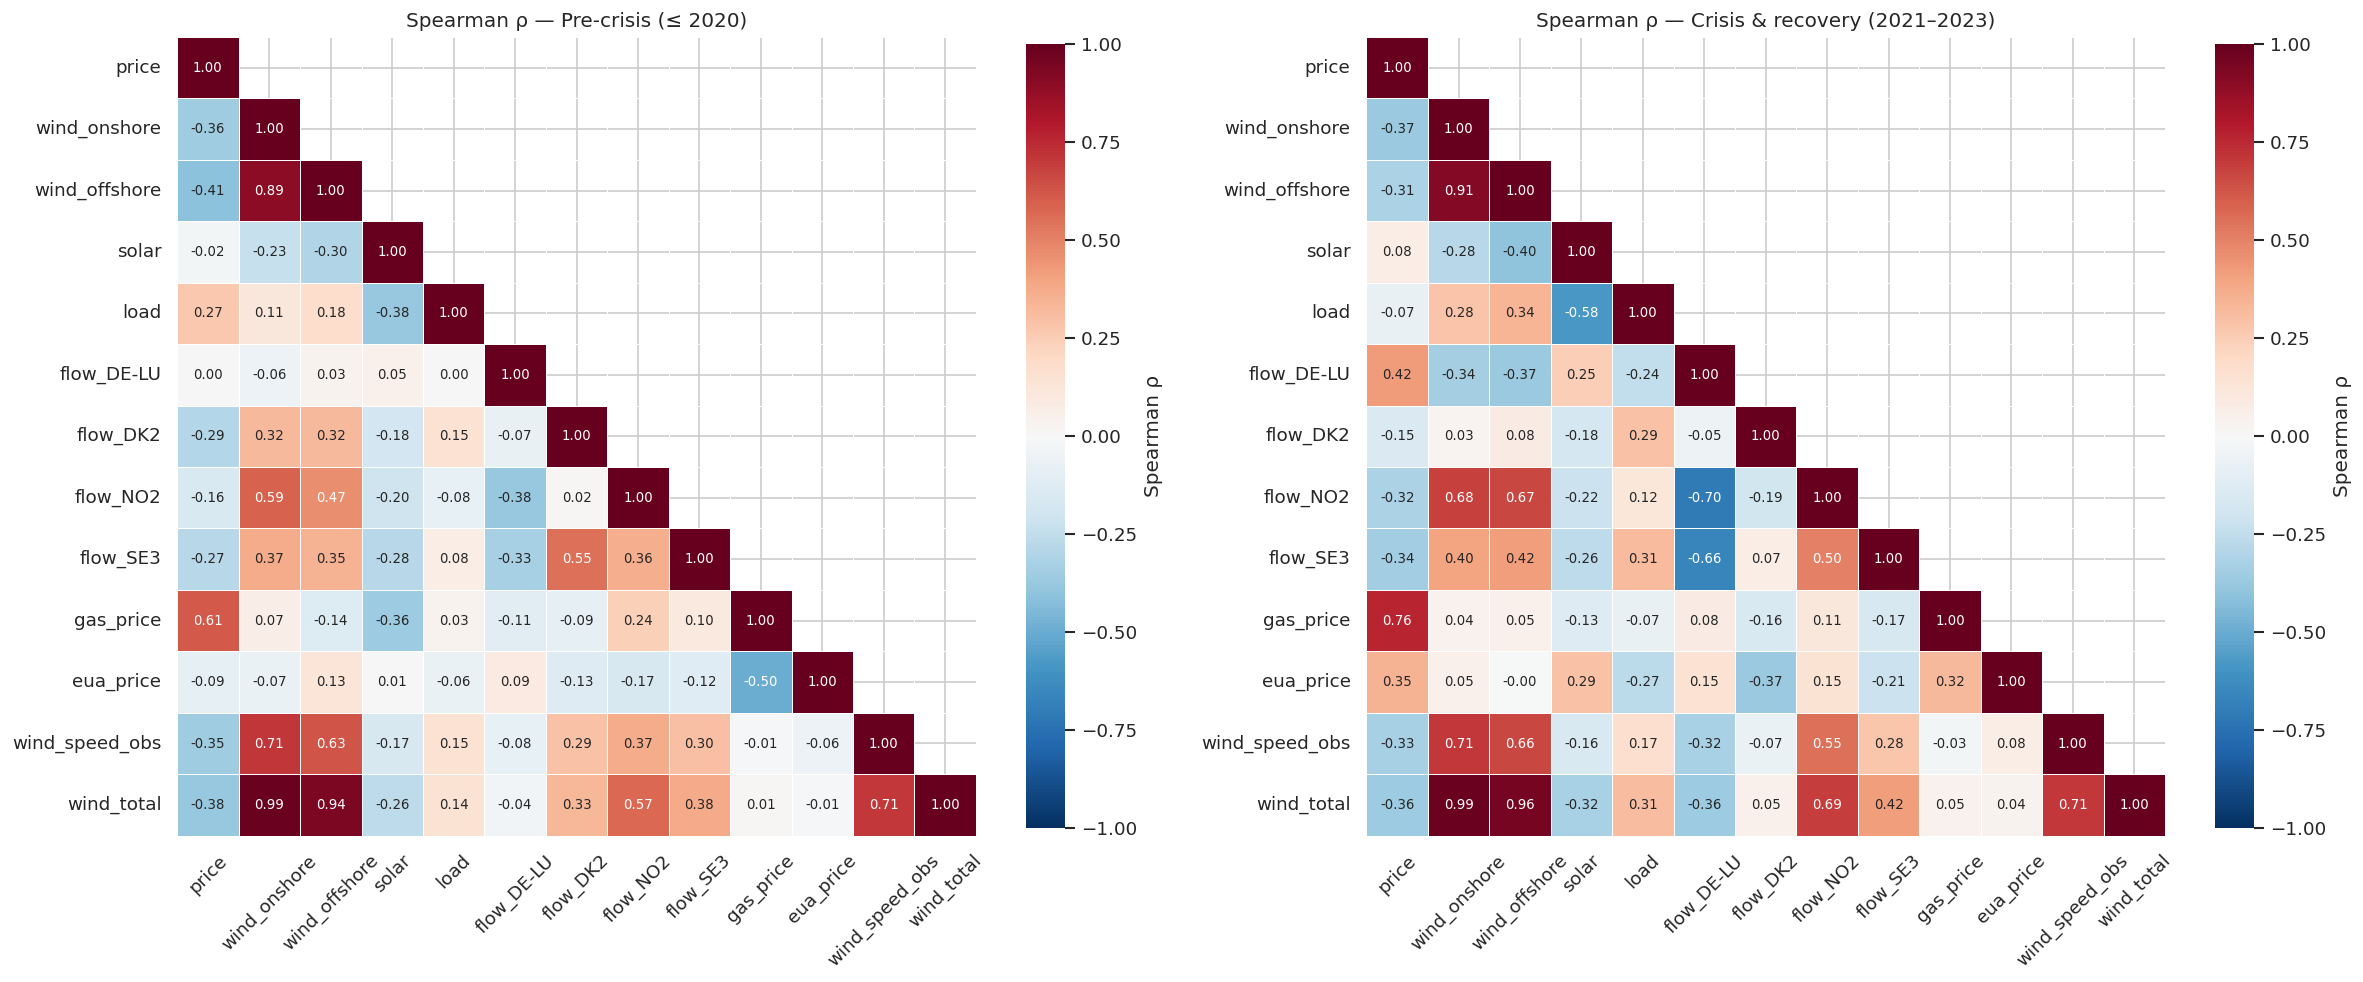

In [27]:
# Split: pre-crisis vs crisis to show feature-importance regime shift
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
relationships.plot_correlation_matrix(
    feat_df.loc[:"2020-12-31"].dropna(how="all"), method="spearman", ax=axes[0]
)
axes[0].set_title("Spearman ρ — Pre-crisis (≤ 2020)")
relationships.plot_correlation_matrix(
    feat_df.loc["2021-01-01":"2023-12-31"].dropna(how="all"), method="spearman", ax=axes[1]
)
axes[1].set_title("Spearman ρ — Crisis & recovery (2021–2023)")
fig.tight_layout()

---
## 12 · Key EDA Findings Summary

| Finding | Evidence |
|---------|----------|
| Price has strong weekly autocorrelation (lag 168h) | ACF plot |
| Negative-price frequency varies widely by year, highest when wind is high | Descriptive stats |
| Wind shows a nonlinear, inverting relationship with price | Wind–price scatter |
| DK1→Germany is the dominant cross-border flow | Net-flow time series |
| Gas emerged as a dominant price driver only post-2021 | Regime-split correlation matrix |
| Load and solar have moderate, mostly linear correlations with price | Correlation matrix |
| Temperature / wind speed at Esbjerg proxies wind output | Climate plots |

**Data gaps to note:**
- No Norwegian hydro reservoir level data (key for medium-term forecasting, Knapik 2017)
- No German day-ahead prices in the dataset (ranked 4th by Li & Becker 2021)
- Climate data only from 2018; renewables data complete from 2015